In [11]:
import tensorflow.compat.v1 as tf

tf.config.set_soft_device_placement(True)
# tf.debugging.set_log_device_placement(True)
# from sklearn.metrics import confusion_matrix
import numpy as np
# from scipy.io import loadmat
import os
# from functools import reduce
# from scipy import signal
import pandas as pd
# from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow import keras as K
from tensorflow.keras.layers import Add, Dense, Activation, Flatten, concatenate, Input, Dropout, LSTM, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, BatchNormalization, PReLU, ELU, ReLU
from tensorflow.keras.models import Sequential, Model, load_model
import matplotlib.pyplot as plt
# import datetime
# get_ipython().run_line_magic('load_ext', 'tensorboard')
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# get_ipython().run_line_magic('matplotlib', 'inline')
# from collections import Counter 
np_load_old = np.load
# from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
# modify the default parameters of np.load
np.load = lambda *a,**k: np_load_old(*a, allow_pickle=True, **k)
np.random.seed(42)
tf.set_random_seed(42)
from sklearn.metrics import classification_report
import argparse
import h5py

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import itertools

In [12]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.figure(figsize=(15,10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=36)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=30)
    plt.yticks(tick_marks, classes, fontsize=30)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=28)

    plt.tight_layout()
    plt.ylabel('True label', fontsize=30)
    plt.xlabel('Predicted label', fontsize=30)

## Load in data

In [13]:
# load new train, validation, and test datasets
# load new train, validation, and test datasets
loadPath = '/home/sz4544/EEG-motor-imagery-main/project/'
os.makedirs(os.path.join(loadPath, "models"), exist_ok=True)
bestModel = '/home/sz4544/EEG-motor-imagery-main/project/models/ftsurrogate_tr1800-val360ts_2CNN.keras'

f_train = h5py.File(os.path.join(loadPath, "train1800_raw_EEG.h5"), "r")
tr_data = f_train['data'][:]
ytr = f_train['tasks'][:]
tr_subjects = f_train['subjects'][:]

f_valid = h5py.File(os.path.join(loadPath, "valid360_raw_EEG.h5"), "r")
val_data = f_valid['data'][:]
yval = f_valid['tasks'][:]
val_subjects = f_valid['subjects'][:]

f_test = h5py.File(os.path.join(loadPath, "test360_raw_EEG.h5"), "r")
ts_data = f_test['data'][:]
yts = f_test['tasks'][:]
ts_subjects = f_test['subjects'][:]

## Normalization

In [14]:
# flatten and reshape data
xtr_s_flattened = np.squeeze(tr_data).ravel().reshape((-1, 64))
xval_s_flattened = np.squeeze(val_data).ravel().reshape((-1, 64))
xts_s_flattened = np.squeeze(ts_data).ravel().reshape((-1, 64))
print(xtr_s_flattened.shape)
print(xval_s_flattened.shape)
print(xts_s_flattened.shape)

# normalize data
scaler = StandardScaler()
Ztr_temp = scaler.fit_transform(xtr_s_flattened)
Zval_temp = scaler.transform(xval_s_flattened)
Zts_temp = scaler.transform(xts_s_flattened)

# flatten and reshape data back
Ztr = np.squeeze(Ztr_temp).ravel().reshape((-1, 640, 64))
Zval = np.squeeze(Zval_temp).ravel().reshape((-1, 640, 64))
Zts = np.squeeze(Zts_temp).ravel().reshape((-1, 640, 64))
print(Ztr.shape)
print(Zval.shape)
print(Zts.shape)

(1152000, 64)
(230400, 64)
(230400, 64)
(1800, 640, 64)
(360, 640, 64)
(360, 640, 64)


In [15]:
x_train = Ztr[..., np.newaxis].astype(np.float32)
x_valid = Zval[..., np.newaxis].astype(np.float32)
x_test = Zts[..., np.newaxis].astype(np.float32)
y_train = pd.get_dummies(ytr).values.astype(np.float32)
y_valid = pd.get_dummies(yval).values.astype(np.float32)
y_test = pd.get_dummies(yts).values.astype(np.float32)

# FT surrogate augmentation: only applied to training data
# For BCI-like tasks with important spatial structure, use channel_indep=False

def ft_surrogate_batch(X, phase_noise_magnitude=0.25, channel_indep=False, random_state=42):
    rng = np.random.default_rng(random_state)
    X_aug = np.empty_like(X, dtype=np.float32)

    n_samples, n_times, n_channels, _ = X.shape

    for i in range(n_samples):
        x = X[i, :, :, 0]  # shape: (n_times, n_channels)

        # FFT along time axis
        Xf = np.fft.rfft(x, axis=0)
        n_freqs = Xf.shape[0]

        # Sample phase noise
        if channel_indep:
            phase_noise = rng.uniform(
                low=0.0,
                high=phase_noise_magnitude * 2 * np.pi,
                size=(n_freqs, n_channels)
            )
        else:
            shared_phase = rng.uniform(
                low=0.0,
                high=phase_noise_magnitude * 2 * np.pi,
                size=(n_freqs, 1)
            )
            phase_noise = np.repeat(shared_phase, n_channels, axis=1)

        # Keep DC and Nyquist (if present) unchanged
        phase_noise[0, :] = 0.0
        if n_times % 2 == 0:
            phase_noise[-1, :] = 0.0

        # Apply phase perturbation and invert FFT
        Xf_aug = Xf * np.exp(1j * phase_noise)
        x_aug = np.fft.irfft(Xf_aug, n=n_times, axis=0).astype(np.float32)

        X_aug[i, :, :, 0] = x_aug

    return X_aug

phase_noise_magnitude = 0.25
channel_indep = False

x_train_ft = ft_surrogate_batch(
    x_train,
    phase_noise_magnitude=phase_noise_magnitude,
    channel_indep=channel_indep,
    random_state=42
)

# Use true augmentation: keep original training samples and append FT-surrogate samples
x_train_aug = np.concatenate([x_train, x_train_ft], axis=0).astype(np.float32)
y_train_aug = np.concatenate([y_train, y_train], axis=0).astype(np.float32)

print("x_train shape:", x_train.shape)
print("x_train_ft shape:", x_train_ft.shape)
print("x_train_aug shape:", x_train_aug.shape)
print("y_train shape:", y_train.shape)
print("y_train_aug shape:", y_train_aug.shape)
print("phase_noise_magnitude:", phase_noise_magnitude)
print("channel_indep:", channel_indep)
print("x_train dtype:", x_train.dtype)
print("x_train_aug dtype:", x_train_aug.dtype)
print("y_train dtype:", y_train.dtype)
print("y_train_aug dtype:", y_train_aug.dtype)

x_train shape: (1800, 640, 64, 1)
x_train_ft shape: (1800, 640, 64, 1)
x_train_aug shape: (3600, 640, 64, 1)
y_train shape: (1800, 4)
y_train_aug shape: (3600, 4)
phase_noise_magnitude: 0.25
channel_indep: False
x_train dtype: float32
x_train_aug dtype: float32
y_train dtype: float32
y_train_aug dtype: float32


## Model architecture

In [16]:
strategy = tf.distribute.MirroredStrategy()
print('Number of devices: {}'.format(strategy.num_replicas_in_sync))

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [17]:
with strategy.scope():
    nodes = 640
    inputs = Input(shape=(nodes, 64, 1))

    conv1 = Conv2D(8, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(inputs)
    batch1 = BatchNormalization()(conv1)
    prelu1 = PReLU()(batch1)
    maxpool1 = MaxPooling2D((2,2))(prelu1)
    conv2 = Conv2D(16, (15,9), strides=(2,1), kernel_initializer = glorot_uniform(seed=42))(maxpool1)
    batch2 = BatchNormalization()(conv2)
    prelu2 = PReLU()(batch2)
    # maxpool2 = MaxPooling2D((5,1))(prelu2)

    flat = Flatten()(prelu2)
    dense1 = Dense(16, activation='sigmoid', kernel_initializer = glorot_uniform(seed=42))(flat)
    drop1 = Dropout(0.2)(dense1)
    predictions = Dense(4, activation='softmax', kernel_initializer = glorot_uniform(seed=42))(drop1)
    model = Model(inputs=inputs,outputs=predictions)
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 640, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 313, 56, 8)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 313, 56, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 313, 56, 8)     │       140,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 156, 28, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 71, 20, 16)     │        17,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 71, 20, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_3 (PReLU)               │ (None, 71, 20, 16)     │        22,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 22720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │       363,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,028 (2.08 MB)

 Trainable params: 544,980 (2.08 MB)

 Non-trainable params: 48 (192.00 B)

None


In [18]:
with strategy.scope():
    opt_adam = K.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08)
    model.compile(loss='categorical_crossentropy', optimizer=opt_adam, metrics=['categorical_accuracy'])

es = EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1, patience=30)
mc = ModelCheckpoint(bestModel, monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True)

In [19]:
history = model.fit(x=x_train_aug, y=y_train_aug, epochs=300, shuffle=True,
                    verbose=1, validation_data = (x_valid, y_valid), callbacks=[es, mc])

Epoch 1/300
INFO:tensorflow:Collective all_reduce tensors: 14 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.2955 - loss: 1.3934
Epoch 1: val_categorical_accuracy improved from None to 0.30000, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/ftsurrogate_tr1800-val360ts_2CNN.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - categorical_accuracy: 0.3233 - loss: 1.3647 - val_categorical_accuracy: 0.3000 - val_loss: 1.3759
Epoch 2/300
108/113 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - categorical_accuracy: 0.4137 - loss: 1.2512
Epoch 2: val_categorical_accuracy improved from 0.30000 to 0.40833, saving model to /home/sz4544/EEG-motor-imagery-main/project/models/ftsurrogate_tr1800-val360ts_2CNN.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - categorical_accuracy: 0.4214 - loss: 1.2539 - val_categorical_accuracy: 0.4083 - val_loss: 1.3015
Epoch 3/300


## Model testing

In [20]:
best_model = tf.keras.models.load_model(bestModel)
yhat = np.argmax(best_model.predict(x_test), axis=1)
ytrue = np.argmax(y_test, axis=1)
print('test acc: {:.2f}%'.format(np.sum(yhat == ytrue) / yts.shape[0] * 100))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
test acc: 49.44%


In [21]:
target_names = ['open one hand', 'imagine open one hand', 'open both hands/feet', 'imagine open both hands/feet']
print(classification_report(ytrue, yhat, target_names=target_names, digits=4))

                              precision    recall  f1-score   support

               open one hand     0.7027    0.2889    0.4094        90
       imagine open one hand     0.4250    0.5667    0.4857        90
        open both hands/feet     0.4900    0.5444    0.5158        90
imagine open both hands/feet     0.5049    0.5778    0.5389        90

                    accuracy                         0.4944       360
                   macro avg     0.5306    0.4944    0.4875       360
                weighted avg     0.5306    0.4944    0.4875       360



In [22]:
cm = confusion_matrix(ytrue, yhat)
cm

array([[26, 34, 24,  6],
       [ 7, 51, 10, 22],
       [ 3, 15, 49, 23],
       [ 1, 20, 17, 52]])

Normalized confusion matrix
[[0.28888889 0.37777778 0.26666667 0.06666667]
 [0.07777778 0.56666667 0.11111111 0.24444444]
 [0.03333333 0.16666667 0.54444444 0.25555556]
 [0.01111111 0.22222222 0.18888889 0.57777778]]


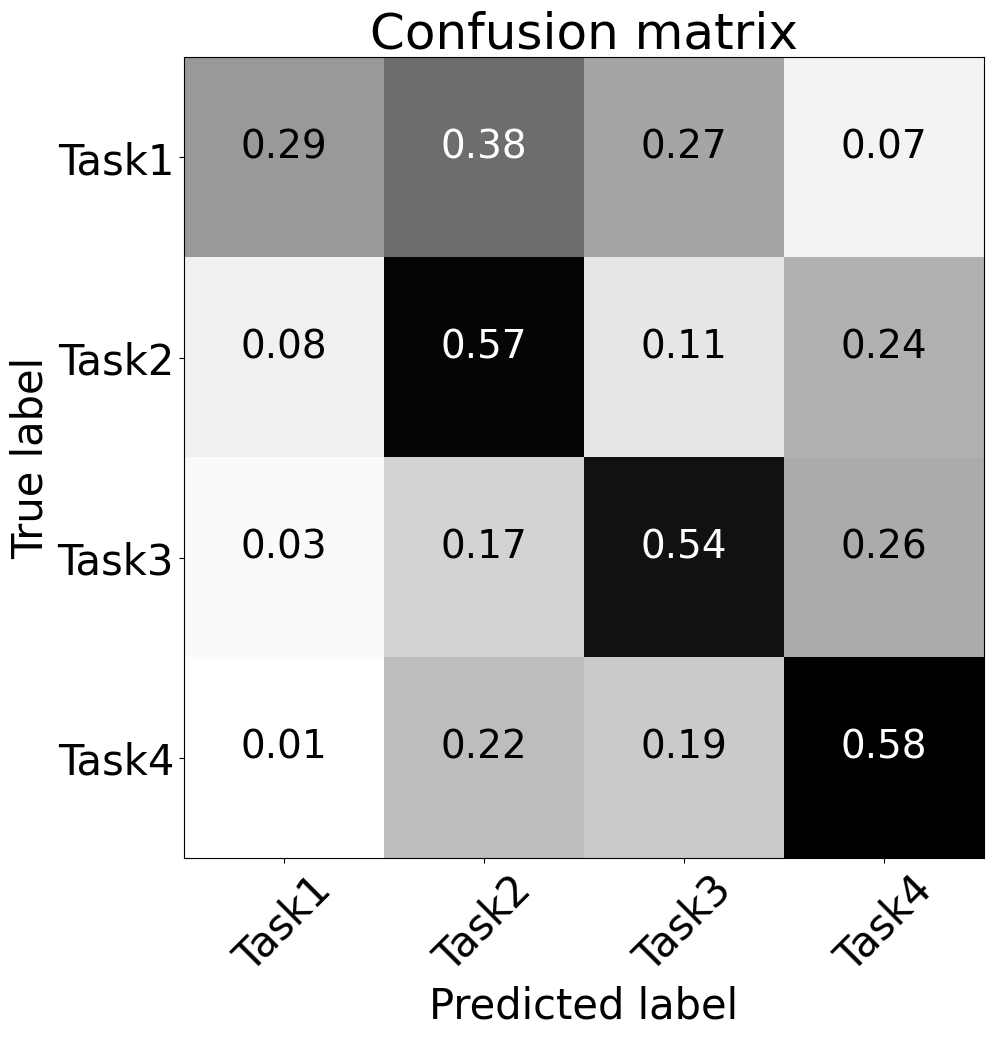

: 

In [ ]:
plot_confusion_matrix(cm, ['Task1', 'Task2', 'Task3', 'Task4'], normalize=True, title='Confusion matrix', cmap=plt.cm.Greys)